In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [16]:
orders=pd.read_csv("../data/processed/clean_orders.csv")
order_items=pd.read_csv("../data/processed/clean_order_items.csv")
payments=pd.read_csv("../data/processed/clean_payments.csv")
customer=pd.read_csv("../data/processed/clean_customers.csv")
products=pd.read_csv("../data/processed/clean_products.csv")
reviews=pd.read_csv("../data/processed/clean_reviews.csv")
category_translation=pd.read_csv("../data/raw/product_category_name_translation.csv")

In [19]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [17]:
for name,df in [('orders',orders),('order items',order_items),('products',products),('customers',customer),('payments',payments),('reviews',reviews)]:
    print(f"\n{'='*40}")
    print(f"{name}:{df.shape[0]} rows,{df.shape[1]} columns")
    print(df.dtypes)
    print(f"Nulls:\n{df.isnull().sum()}")
    
                


orders:99441 rows,9 columns
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
is_delivered                       bool
dtype: object
Nulls:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
is_delivered                        0
dtype: int64

order items:112650 rows,7 columns
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value 

# REVENUE DISTRIBUTION

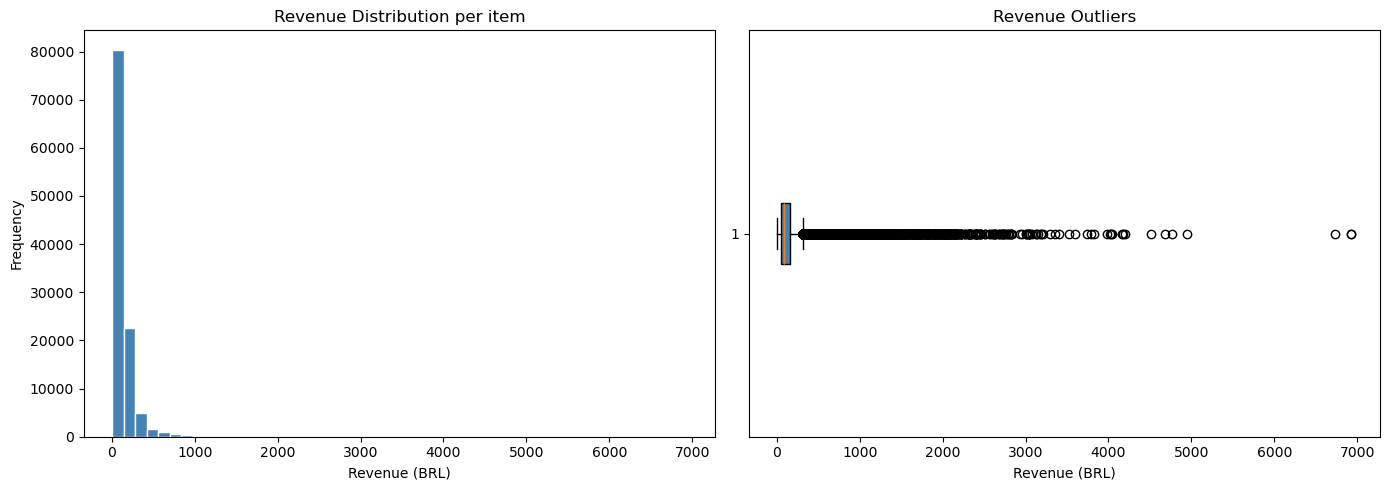

In [11]:
# 1.Merging order_items with orders

df=order_items.merge(orders,on='order_id')
df['revenue']=df['price']+df['freight_value']
fig,axes=plt.subplots(1,2,figsize=(14,5))

axes[0].hist(df['revenue'],bins=50,color='steelblue',edgecolor='white')
axes[0].set_title('Revenue Distribution per item')
axes[0].set_xlabel('Revenue (BRL)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['revenue'],vert=False,patch_artist=True,boxprops=dict(facecolor='steelblue'))
axes[1].set_title('Revenue Outliers')
axes[1].set_xlabel('Revenue (BRL)')

plt.tight_layout()
plt.savefig('revenue_distribution.png',dpi=150)
plt.show()

# Monthly revenue trend

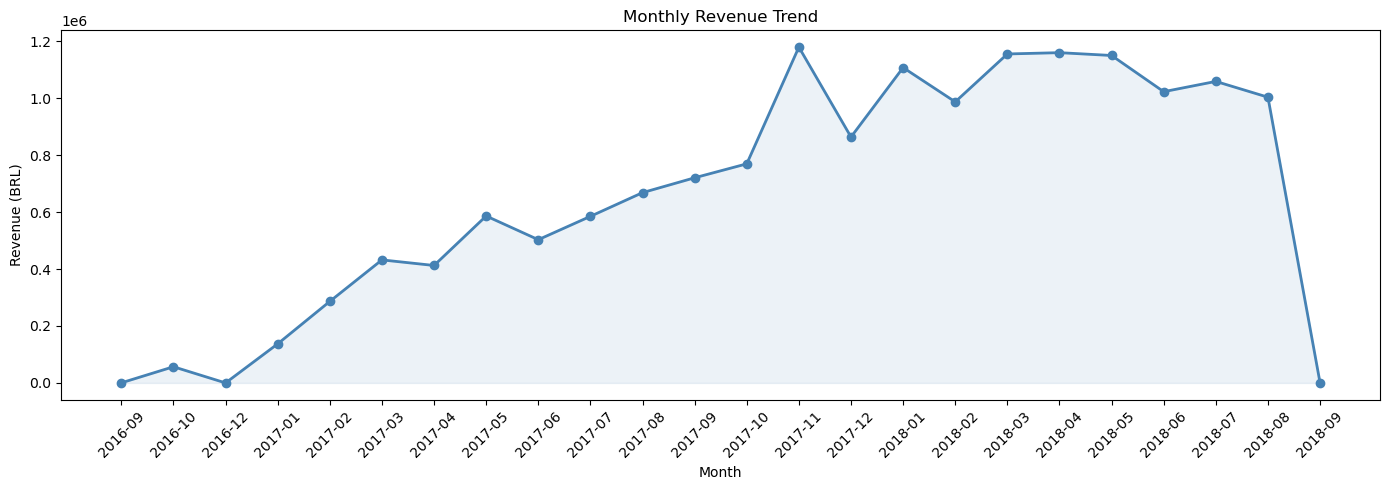

In [13]:
df['order_purchase_timestamp']=pd.to_datetime(df['order_purchase_timestamp'])
df['month']=df['order_purchase_timestamp'].dt.to_period('M')

monthly_rev= df.groupby('month')['revenue'].sum().reset_index()
monthly_rev['month'] = monthly_rev['month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_rev['month'], monthly_rev['revenue'],marker='o', color='steelblue', linewidth=2)
plt.fill_between(range(len(monthly_rev)), monthly_rev['revenue'], alpha=0.1, color='steelblue')
plt.xticks(range(len(monthly_rev)), monthly_rev['month'], rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()

# Top- 10 categories

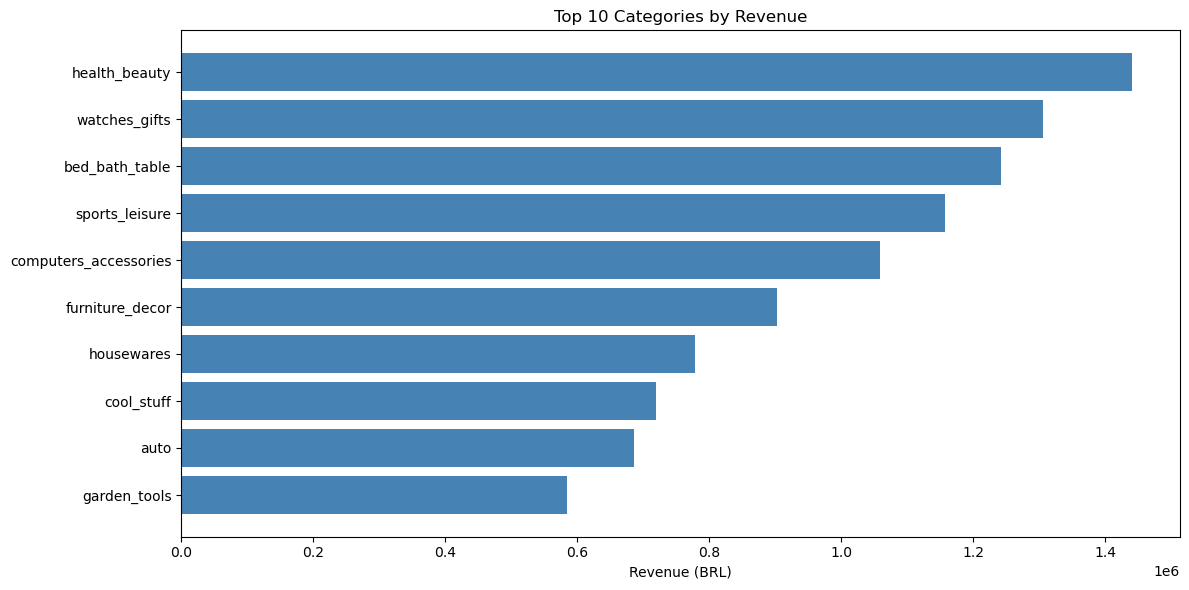

In [21]:
# Merge with products and translation
df_category = order_items.merge(products, on='product_id')
df_category = df_category.merge(category_translation,left_on='product_category_name', right_on='product_category_name', how='left')
df_category['revenue'] = df_category['price'] + df_category['freight_value']
df_category['category'] = df_category['product_category_name_english'].fillna('Other')

top_category = df_category.groupby('category')['revenue'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
bars = plt.barh(top_category['category'][::-1], top_category['revenue'][::-1],color='steelblue')
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Revenue (BRL)')
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150)
plt.show()

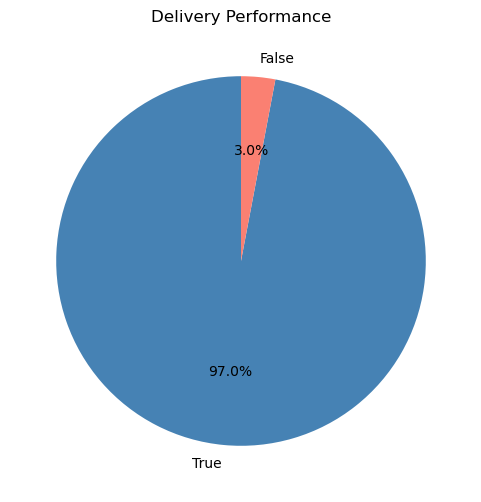

In [22]:
# Delivery Performance
delivery = orders['is_delivered'].value_counts().reset_index()
delivery.columns = ['status', 'count']

plt.figure(figsize=(6, 6))
plt.pie(delivery['count'], labels=delivery['status'], autopct='%1.1f%%',colors=['steelblue', 'salmon'], startangle=90)
plt.title('Delivery Performance')
plt.savefig('delivery_performance.png', dpi=150)
plt.show()

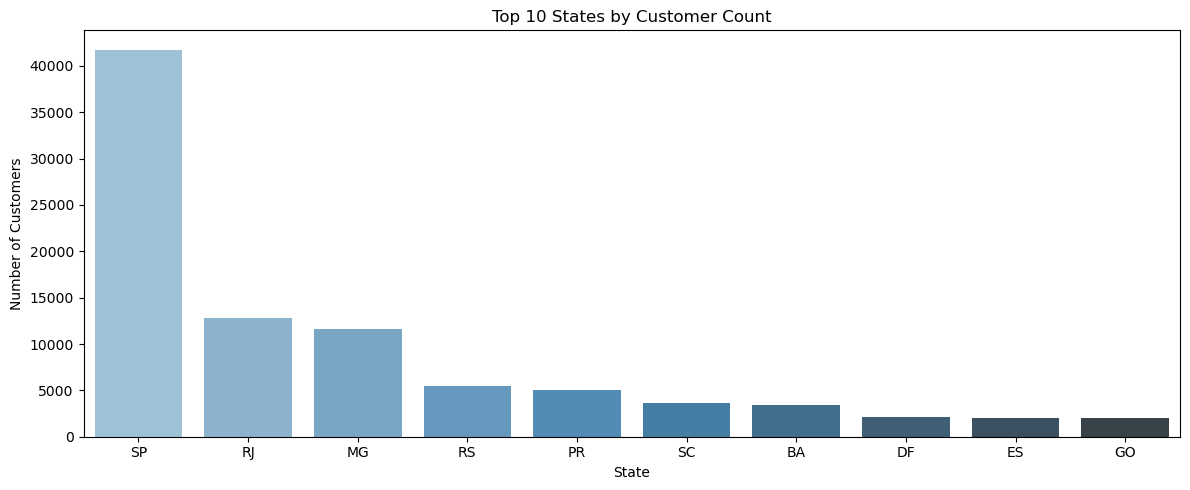

In [24]:
# Customer state distribution
top_states = customer['customer_state'].value_counts().head(10).reset_index()
top_states.columns = ['state', 'count']

plt.figure(figsize=(12, 5))
sns.barplot(data=top_states, x='state', y='count', palette='Blues_d')
plt.title('Top 10 States by Customer Count')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('customer_states.png', dpi=150)
plt.show()

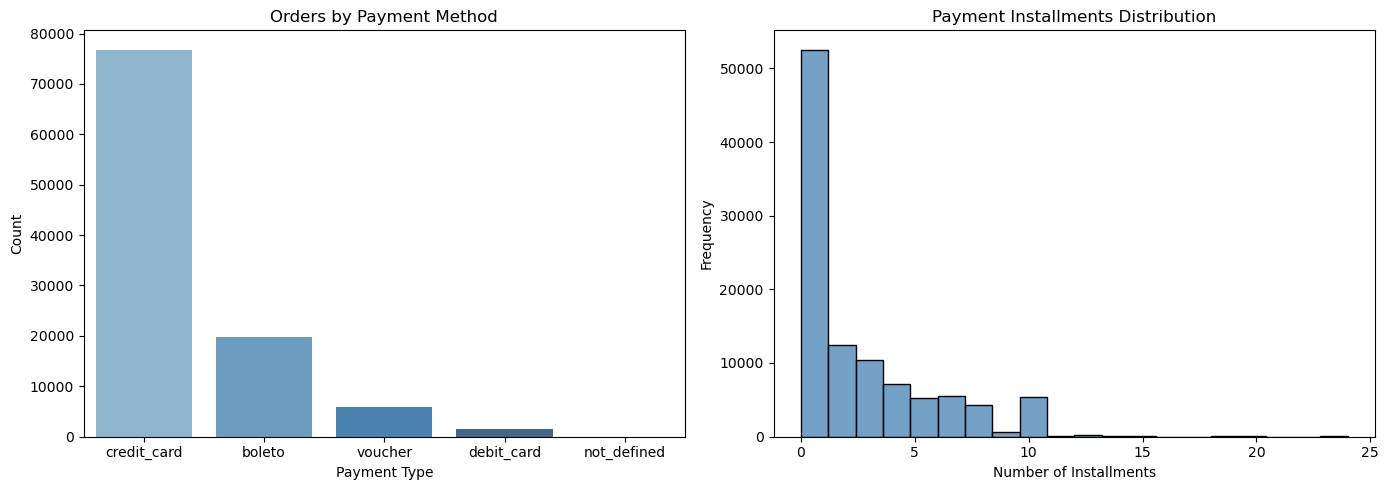

Average Installments: 2.85


In [25]:
# Payment Analysis

payment_counts = payments['payment_type'].value_counts().reset_index()
payment_counts.columns = ['payment_type', 'count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=payment_counts, x='payment_type', y='count', 
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Orders by Payment Method')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Count')

sns.histplot(payments['payment_installments'], bins=20, 
             color='steelblue', ax=axes[1])
axes[1].set_title('Payment Installments Distribution')
axes[1].set_xlabel('Number of Installments')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('payment_analysis.png', dpi=150)
plt.show()

print(f"Average Installments: {payments['payment_installments'].mean():.2f}")

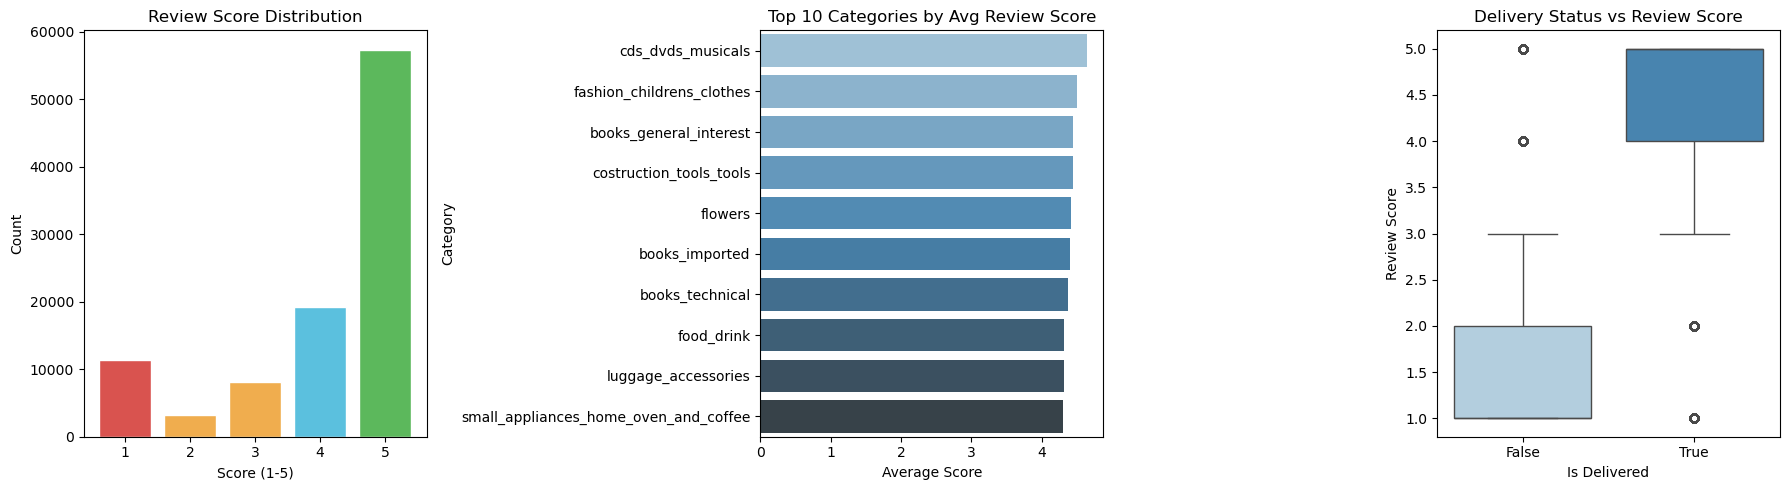

Overall Average Review Score: 4.09


In [28]:
# Review Score analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

review_counts = reviews['review_score'].value_counts().sort_index().reset_index()
review_counts.columns = ['score', 'count']
colors = ['#d9534f','#f0ad4e','#f0ad4e','#5bc0de','#5cb85c']

axes[0].bar(review_counts['score'], review_counts['count'], 
            color=colors, edgecolor='white')
axes[0].set_title('Review Score Distribution')
axes[0].set_xlabel('Score (1-5)')
axes[0].set_ylabel('Count')

df_reviews = order_items.merge(orders[['order_id']], on='order_id')
df_reviews = df_reviews.merge(reviews[['order_id','review_score']], on='order_id')
df_reviews = df_reviews.merge(products[['product_id','product_category_name']], on='product_id')
df_reviews = df_reviews.merge(category_translation, left_on='product_category_name', right_on='product_category_name', how='left')
df_reviews['category'] = df_reviews['product_category_name_english'].fillna('Other')

avg_score = df_reviews.groupby('category')['review_score'].mean().nlargest(10).reset_index()

sns.barplot(data=avg_score, x='review_score', y='category', 
            palette='Blues_d', ax=axes[1])
axes[1].set_title('Top 10 Categories by Avg Review Score')
axes[1].set_xlabel('Average Score')
axes[1].set_ylabel('Category')

df_del = orders[['order_id','is_delivered']].merge(
    reviews[['order_id','review_score']], on='order_id')

sns.boxplot(data=df_del, x='is_delivered', y='review_score', 
            palette='Blues', ax=axes[2])
axes[2].set_title('Delivery Status vs Review Score')
axes[2].set_xlabel('Is Delivered')
axes[2].set_ylabel('Review Score')

plt.tight_layout()
plt.savefig('review_analysis.png', dpi=150)
plt.show()

print(f"Overall Average Review Score: {reviews['review_score'].mean():.2f}")